# SNAP Payment Error Rate — Error Detection Model
## Full Performance Evaluation

### HUMAID BILLOO

## 0. Install dependencies

In [1]:

# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn imbalanced-learn --break-system-packages -q


## 1. Imports & configuration

In [2]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, roc_curve,
    brier_score_loss, log_loss,
    matthews_corrcoef, cohen_kappa_score,
    balanced_accuracy_score, classification_report
)
from imblearn.over_sampling import SMOTENC

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH         = 'Data_UVA_SNAProject.csv'
PRIMARY_THRESHOLD = 0.65
HIGH_CONF        = 0.70
SNAP_BENEFIT     = {1:298,2:546,3:785,4:994,5:1183,6:1421,7:1571,8:1789}
CAT_COLS         = ['va_region','grouprace','job_category','max_educ']
SEED             = 42
print('Imports OK')


Imports OK


## 2. Load & inspect data

Before modelling, we check class balance, label quality, and temporal span.
These directly affect which metrics to trust.


In [3]:
df = pd.read_csv(DATA_PATH)
mask = df['error_target'].notna()
df   = df[mask].copy()

# ── Remove "Not subject to review" cases ─────────────────────────────────────
# These 148 cases are definitionally exempt from QC review 
if 'Type' in df.columns:
    n_before = len(df)
    df = df[df['Type'] != '2. Not subject to review'].copy()
    n_removed = n_before - len(df)
    print(f"Removed {n_removed} 'Not subject to review' cases (not eligible for error)")

y    = df['error_target'].astype(int)
n    = len(df)

print(f"Rows (after filter) : {n:,}")
print(f"Date range          : {df['mdate'].min()} → {df['mdate'].max()}")
print(f"Unique months       : {df['mdate'].nunique()}")

print("\n── Class balance ──")
vc = y.value_counts().sort_index()
for val, cnt in vc.items():
    label = 'ERROR   ' if val == 1 else 'NO ERROR'
    bar   = '█' * int(cnt / n * 50)
    print(f"  {label}  ({val})  {cnt:,}  ({cnt/n:.1%})  {bar}")

print("\n── Review completeness (Type column) ──")
if 'Type' in df.columns:
    print(df['Type'].value_counts().to_string())
    n_incomplete = df['Type'].eq('3. Incomplete').sum()
    print(f"\n  ⚠  {n_incomplete:,} incomplete reviews — labels may be noisy")


Removed 148 'Not subject to review' cases (not eligible for error)
Rows (after filter) : 3,510
Date range          : 2021m10 → 2025m5
Unique months       : 42

── Class balance ──
  NO ERROR  (0)  2,153  (61.3%)  ██████████████████████████████
  ERROR     (1)  1,357  (38.7%)  ███████████████████

── Review completeness (Type column) ──
Type
1. Complete      2708
3. Incomplete     802

  ⚠  802 incomplete reviews — labels may be noisy


## 3. Feature engineering

We compute derived features that proxy for the conditions most likely to produce errors:
- **Income rounding flags** — caseworkers sometimes round estimates, creating discrepancies
- **Share of issuance** — how close the benefit is to the household maximum
- **Complex household score** — elderly + disabled + children flags combined
- **Income source shares** — wage vs. unearned income have different verification difficulty


In [4]:
def engineer(df):
    d   = df.copy()
    ern = d.get('case_ern_incm_amt',   pd.Series(0,index=d.index)).fillna(0)
    urn = d.get('case_uern_incm_amt',  pd.Series(0,index=d.index)).fillna(0)
    srn = d.get('case_slf_ern_incm_amt',pd.Series(0,index=d.index)).fillna(0)
    shl = d.get('tot_shl_cost_amt',    pd.Series(0,index=d.index)).fillna(0)
    iss = d.get('Issuance',            pd.Series(np.nan,index=d.index))
    fs  = d.get('family_size',         pd.Series(1,index=d.index)).replace(0,np.nan)
    cas = d.get('caseload',            pd.Series(0,index=d.index)).fillna(0)
    dss = d.get('dss_tenure',          pd.Series(0,index=d.index)).fillna(0)
    jt  = d.get('job_tenure',          pd.Series(0,index=d.index)).fillna(0)

    d['total_income']    = ern + urn + srn
    ti = d['total_income'] + 1
    d['round_income']    = ((ern!=0)&(ern==ern.round())).astype(int)
    d['round_income_un'] = ((urn!=0)&(urn==urn.round())).astype(int)
    d['share_rent']      = shl / ti
    d['flag_inchh']      = ((fs>=3)&((ern+urn)>=1500)).astype(int)
    d['inc_cap']         = d['total_income'] / fs
    d['caseload_cap']    = cas / (dss+1)
    d['max_snap']        = fs.map(SNAP_BENEFIT)
    d['share_issuance']  = iss / d['max_snap']
    d['earned_share']    = ern / ti
    d['unearned_share']  = urn / ti
    d['self_empl_share'] = srn / ti
    d['med_exp_flag']    = (d.get('med_exp_amt',pd.Series(0,index=d.index)).fillna(0)>0).astype(int)
    d['shelter_flag']    = (shl>0).astype(int)
    d['income_deviation']= iss - d['inc_cap'].fillna(0)
    d['complex_hh']      = (d.get('is_children',pd.Series(0,index=d.index)).fillna(0)
                           +d.get('is_disable', pd.Series(0,index=d.index)).fillna(0)
                           +d.get('is_old',     pd.Series(0,index=d.index)).fillna(0))
    d['job_tenure_sq']   = np.sqrt(jt.clip(lower=0))
    d['caseload_sq']     = np.sqrt(cas.clip(lower=0))
    return d

CONT_FEATS = [
    'case_ern_incm_amt','case_uern_incm_amt','case_slf_ern_incm_amt',
    'unit_disable','unit_children','is_married','is_old','case_nonenglish',
    'flag_monoeth','flag_monolang','is_children','is_disable','is_separated','self_empl',
    'med_age','av_age','family_size','dss_tenure','job_tenure','caseload',
    'tot_shl_cost_amt','homeless_allow_amt','med_exp_amt','bas_utl_allow_amt','chld_sup_exp_amt',
    'aboveavg_uern_fips','aboveavg_ern_fips','aboveavg_shl_fips','move_flag','Issuance',
    'total_income','round_income','round_income_un','share_rent','flag_inchh',
    'inc_cap','caseload_cap','share_issuance','earned_share','unearned_share',
    'self_empl_share','med_exp_flag','shelter_flag','income_deviation',
    'complex_hh','job_tenure_sq','caseload_sq',
]

d_eng         = engineer(df)

# ── Explicit exclusion guard ──────────────────────────────────────────────────
# These columns must NEVER enter the feature matrix.
EXCLUDED_COLS = {
    'Type',           
    'main_error_type',                
    'Error',           
    'error_target',  
}

keep = [f for f in CONT_FEATS if f in d_eng.columns and f not in EXCLUDED_COLS] + [c for c in CAT_COLS if c in d_eng.columns and c not in EXCLUDED_COLS]
X_raw = d_eng[keep].copy()
for c in CAT_COLS:
    if c in X_raw.columns:
        X_raw[c] = pd.Categorical(X_raw[c]).codes.astype(float)
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
cat_indices = [X_raw.columns.get_loc(c) for c in CAT_COLS if c in X_raw.columns]
cat_col_names = [c for c in CAT_COLS if c in X_raw.columns]

print(f"Feature matrix : {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features")
print(f"Categorical cols ({len(cat_indices)}): {cat_col_names}")
print("\nSample (first 3 rows):")
X_raw.head(3)


Feature matrix : 3,510 rows × 51 features
Categorical cols (4): ['va_region', 'grouprace', 'job_category', 'max_educ']

Sample (first 3 rows):


,case_ern_incm_amt,case_uern_incm_amt,case_slf_ern_incm_amt,unit_disable,unit_children,is_married,is_old,case_nonenglish,flag_monoeth,flag_monolang,...,med_exp_flag,shelter_flag,income_deviation,complex_hh,job_tenure_sq,caseload_sq,va_region,grouprace,job_category,max_educ
0,3464.7400,0.0000,0.0000,0,5,1,0,0,1,1,...,0,1,-145.4567,1.0000,0.0000,27.8029,0.0000,0.0000,0.0000,3.0000
1,1545.7400,0.0000,0.0000,0,2,0,0,0,0,1,...,0,1,139.7533,1.0000,0.0000,64.1327,2.0000,1.0000,0.0000,3.0000
2,0.0000,1040.0000,0.0000,1,0,0,1,0,1,1,...,0,1,-910.0000,2.0000,0.0000,40.0000,3.0000,0.0000,0.0000,3.0000


## 4. Model training — XGBoost + SMOTENC

In [5]:
PARAMS = dict(
    n_estimators=500, max_depth=4, learning_rate=0.03,
    min_child_weight=10, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=2.0, reg_lambda=2.0,
    eval_metric='aucpr', objective='binary:logistic',
    random_state=SEED, verbosity=0
)
_all_cols_df = pd.get_dummies(X_raw, columns=cat_col_names, drop_first=False)
all_cols     = list(_all_cols_df.columns)

cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_prob     = np.zeros(n)
X_np       = X_raw.values
y_np       = y.values
fold_stats = []

def align_ohe(df, canonical_cols):
    """Ensure df has exactly canonical_cols, adding zeros for any missing."""
    for c in canonical_cols:
        if c not in df.columns: df[c] = 0
    return df[canonical_cols]

print("Running 5-fold CV with SMOTENC inside each fold...\n")
for fold, (tr, val) in enumerate(cv.split(X_np, y_np), 1):
    sm           = SMOTENC(categorical_features=cat_indices, random_state=SEED, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X_np[tr], y_np[tr])

    X_res_df  = pd.DataFrame(X_res,     columns=X_raw.columns)
    X_val_df  = pd.DataFrame(X_np[val], columns=X_raw.columns)

    # OHE then align BOTH train and val to the same canonical columns
    X_res_ohe = align_ohe(pd.get_dummies(X_res_df, columns=cat_col_names, drop_first=False), all_cols)
    X_val_ohe = align_ohe(pd.get_dummies(X_val_df, columns=cat_col_names, drop_first=False), all_cols)

    m = xgb.XGBClassifier(**PARAMS)
    m.fit(X_res_ohe.values, y_res)
    fold_probs  = m.predict_proba(X_val_ohe.values)[:, 1]
    y_prob[val] = fold_probs

    fold_pred = (fold_probs >= PRIMARY_THRESHOLD).astype(int)
    y_val     = y_np[val]
    n_synth   = len(X_res) - len(tr)

    fold_stats.append({
        'Fold'       : fold,
        'Val N'      : len(val),
        'Synthetic'  : n_synth,
        'ROC-AUC'    : round(roc_auc_score(y_val, fold_probs), 4),
        'PR-AUC'     : round(average_precision_score(y_val, fold_probs), 4),
        f'Precision@{PRIMARY_THRESHOLD}' : round(precision_score(y_val, fold_pred, zero_division=0), 4),
        f'Recall@{PRIMARY_THRESHOLD}'    : round(recall_score(y_val, fold_pred, zero_division=0), 4),
        f'F1@{PRIMARY_THRESHOLD}'        : round(f1_score(y_val, fold_pred, zero_division=0), 4),
        'Flagged'    : int(fold_pred.sum()),
    })
    print(f"  Fold {fold}: train={len(tr):,} + {n_synth} synthetic  →  val={len(val):,}  "
          f"ROC-AUC={fold_stats[-1]['ROC-AUC']:.4f}  "
          f"Prec@{PRIMARY_THRESHOLD}={fold_stats[-1][f'Precision@{PRIMARY_THRESHOLD}']:.4f}")

y_pred_default  = (y_prob >= 0.50).astype(int)
y_pred_primary  = (y_prob >= PRIMARY_THRESHOLD).astype(int)
y_pred_highconf = (y_prob >= HIGH_CONF).astype(int)
print("\nDone. Feature matrix width:", len(all_cols), "columns")


Running 5-fold CV with SMOTENC inside each fold...

  Fold 1: train=2,808 + 638 synthetic  →  val=702  ROC-AUC=0.7557  Prec@0.65=0.6171
  Fold 2: train=2,808 + 638 synthetic  →  val=702  ROC-AUC=0.7470  Prec@0.65=0.6272
  Fold 3: train=2,808 + 636 synthetic  →  val=702  ROC-AUC=0.7475  Prec@0.65=0.6467
  Fold 4: train=2,808 + 636 synthetic  →  val=702  ROC-AUC=0.7445  Prec@0.65=0.5987
  Fold 5: train=2,808 + 636 synthetic  →  val=702  ROC-AUC=0.7598  Prec@0.65=0.6761

Done. Feature matrix width: 64 columns


## 4b. Cross-validation results — fold-by-fold stability

A single train/test split can be lucky or unlucky. The table below shows performance on **each held-out fold** independently.
If AUC swings more than ±0.03 across folds, the model is unstable and results shouldn't be trusted at face value.

High variance across folds usually means the features don't generalise well — either due to overfitting,
temporal drift (errors cluster in certain months), or regional patterns the model handles differently fold-to-fold.

Cross-Validation Results (5-fold, SMOTENC inside each fold)
        Val N  Synthetic  ROC-AUC  PR-AUC  Precision@0.65  Recall@0.65  F1@0.65  Flagged
1    702.0000   638.0000   0.7557  0.6054          0.6171       0.3971   0.4832 175.0000
2    702.0000   638.0000   0.7470  0.5893          0.6272       0.3897   0.4807 169.0000
3    702.0000   636.0000   0.7475  0.6009          0.6467       0.3579   0.4608 150.0000
4    702.0000   636.0000   0.7445  0.5968          0.5987       0.3469   0.4393 157.0000
5    702.0000   636.0000   0.7598  0.6020          0.6761       0.3542   0.4649 142.0000
Mean 702.0000   636.8000   0.7509  0.5989          0.6332       0.3692   0.4658 158.6000
Std    0.0000     1.0954   0.0065  0.0062          0.0296       0.0226   0.0177  13.5019

✓  AUC std = 0.0065 — model is stable across folds.


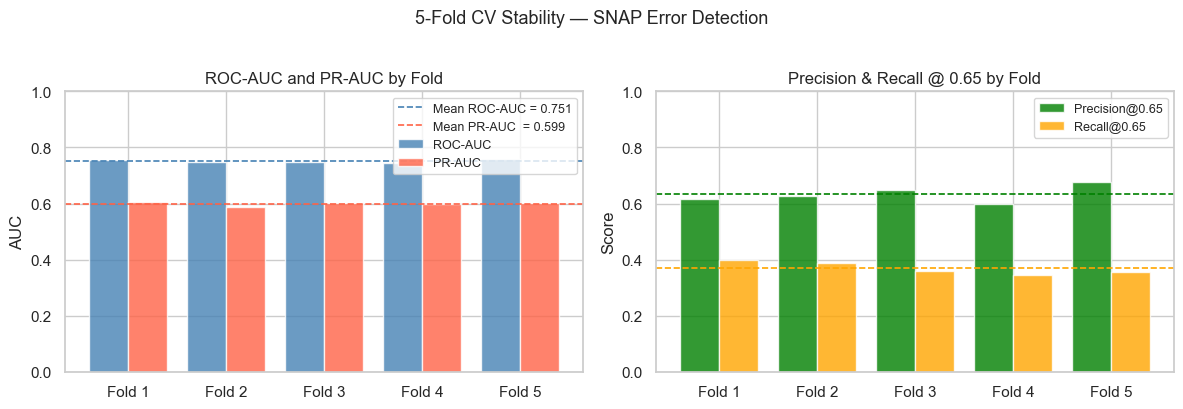

In [6]:
# ── Cross-validation fold-by-fold summary ───────────────────────────────────
fold_df = pd.DataFrame(fold_stats).set_index('Fold')

# Append mean ± std rows
means = fold_df.mean(numeric_only=True).rename('Mean')
stds  = fold_df.std(numeric_only=True).rename('Std')
fold_summary = pd.concat([fold_df, means.to_frame().T, stds.to_frame().T])

# Display
print("Cross-Validation Results (5-fold, SMOTENC inside each fold)")
print("=" * 75)
print(fold_summary.to_string(float_format='{:.4f}'.format))
print()

# Stability check
auc_std = fold_df['ROC-AUC'].std()
if auc_std > 0.03:
    print(f"⚠  AUC std = {auc_std:.4f} — HIGH VARIANCE across folds.")
    print("   Results may not generalise. Consider time-based CV split.")
else:
    print(f"✓  AUC std = {auc_std:.4f} — model is stable across folds.")

# Plot fold-by-fold AUC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
aucs = fold_df['ROC-AUC'].values
prcs = fold_df['PR-AUC'].values
x    = np.arange(1, 6)
ax.bar(x - 0.2, aucs, 0.4, label='ROC-AUC', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, prcs, 0.4, label='PR-AUC',  color='tomato',    alpha=0.8)
ax.axhline(aucs.mean(), color='steelblue', ls='--', lw=1.2, label=f'Mean ROC-AUC = {aucs.mean():.3f}')
ax.axhline(prcs.mean(), color='tomato',    ls='--', lw=1.2, label=f'Mean PR-AUC  = {prcs.mean():.3f}')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylim([0, 1]); ax.set_ylabel('AUC')
ax.set_title('ROC-AUC and PR-AUC by Fold')
ax.legend(fontsize=9)

ax = axes[1]
prec_col = f'Precision@{PRIMARY_THRESHOLD}'
rec_col  = f'Recall@{PRIMARY_THRESHOLD}'
precs_f  = fold_df[prec_col].values
recs_f   = fold_df[rec_col].values
ax.bar(x - 0.2, precs_f, 0.4, label=f'Precision@{PRIMARY_THRESHOLD}', color='green',  alpha=0.8)
ax.bar(x + 0.2, recs_f,  0.4, label=f'Recall@{PRIMARY_THRESHOLD}',    color='orange', alpha=0.8)
ax.axhline(precs_f.mean(), color='green',  ls='--', lw=1.2)
ax.axhline(recs_f.mean(),  color='orange', ls='--', lw=1.2)
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylim([0, 1]); ax.set_ylabel('Score')
ax.set_title(f'Precision & Recall @ {PRIMARY_THRESHOLD} by Fold')
ax.legend(fontsize=9)

plt.suptitle('5-Fold CV Stability — SNAP Error Detection', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 5. Performance metrics — complete evaluation

We evaluate at **three thresholds**:
- **0.50** — the default "is it more likely error than not?"  
- **0.65** — our primary operating threshold, balances precision and workload  
- **0.70** — high-confidence tier, highest precision, fewest flags  

Each metric below is explained in the context of the SNAP review workflow.


In [7]:
def all_metrics(y_true, y_prob, threshold, label):
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        # ── Threshold-based ─────────────────────────────
        'Accuracy'                : accuracy_score(y_true, y_pred),
        'Balanced Accuracy'       : balanced_accuracy_score(y_true, y_pred),
        'Precision'               : precision_score(y_true, y_pred, zero_division=0),
        'Recall  (Sensitivity)'   : recall_score(y_true, y_pred, zero_division=0),
        'Specificity'             : tn / (tn + fp) if (tn+fp)>0 else 0,
        'F1 Score'                : f1_score(y_true, y_pred, zero_division=0),
        'F2 Score'                : fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'F0.5 Score'              : fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
        'False Positive Rate'     : fp / (fp + tn) if (fp+tn)>0 else 0,
        'False Discovery Rate'    : fp / (fp + tp) if (fp+tp)>0 else 0,
        'False Omission Rate'     : fn / (fn + tn) if (fn+tn)>0 else 0,
        'Negative Pred Value'     : tn / (tn + fn) if (tn+fn)>0 else 0,
        'Matthews Corr Coef'      : matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa"           : cohen_kappa_score(y_true, y_pred),
        'Cases Flagged'           : int(y_pred.sum()),
        '% of Caseload Flagged'   : y_pred.mean(),
        # ── Probabilistic (threshold-independent) ───────
        'ROC-AUC'                 : roc_auc_score(y_true, y_prob),
        'PR-AUC (Avg Precision)'  : average_precision_score(y_true, y_prob),
        'Brier Score'             : brier_score_loss(y_true, y_prob),
        'Log Loss'                : log_loss(y_true, y_prob),
    }
    return pd.Series(metrics, name=label)

m50 = all_metrics(y, y_prob, 0.50, 'Threshold 0.50')
m65 = all_metrics(y, y_prob, PRIMARY_THRESHOLD, f'Threshold {PRIMARY_THRESHOLD}')
m70 = all_metrics(y, y_prob, HIGH_CONF, f'Threshold {HIGH_CONF}')

results_df = pd.concat([m50, m65, m70], axis=1)
results_df


,Threshold 0.50,Threshold 0.65,Threshold 0.7
Accuracy,0.6994,0.6729,0.6481
Balanced Accuracy,0.6936,0.6168,0.5712
Precision,0.6000,0.6318,0.6201
Recall (Sensitivity),0.6676,0.3692,0.2321
Specificity,0.7195,0.8644,0.9104
F1 Score,0.6320,0.4660,0.3378
F2 Score,0.6529,0.4027,0.2653
F0.5 Score,0.6124,0.5531,0.4647
False Positive Rate,0.2805,0.1356,0.0896
False Discovery Rate,0.4000,0.3682,0.3799


## 6. PLACE HOLDER


## 7. Confusion matrix (at threshold = 0.65)

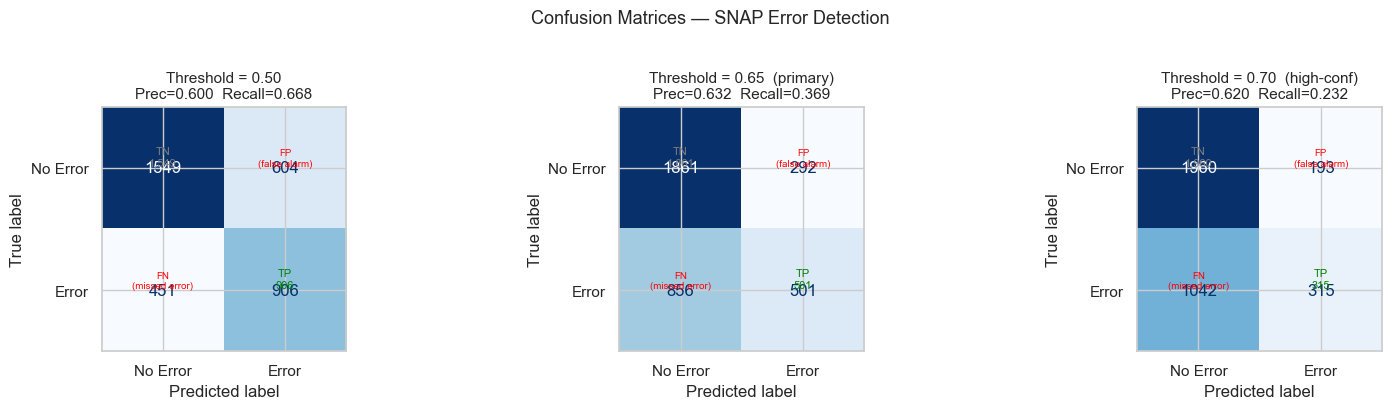


At threshold = 0.65:
  True Positives  (TP) = 501  — real errors correctly flagged for review
  False Positives (FP) = 292  — clean cases wrongly flagged (wasted reviewer time)
  False Negatives (FN) = 856  — real errors missed entirely (still on PER)
  True Negatives  (TN) = 1,861  — clean cases correctly cleared


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (thresh, preds, title) in zip(axes, [
    (0.50, y_pred_default,  'Threshold = 0.50'),
    (0.65, y_pred_primary,  'Threshold = 0.65  (primary)'),
    (0.70, y_pred_highconf, 'Threshold = 0.70  (high-conf)'),
]):
    cm  = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Error', 'Error'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nPrec={tp/(tp+fp):.3f}  Recall={tp/(tp+fn):.3f}', fontsize=11)

    # Annotate quadrants
    ax.text(0, 0, f'TN\n{tn:,}', ha='center', va='bottom', fontsize=8, color='gray')
    ax.text(1, 0, f'FP\n(false alarm)', ha='center', va='bottom', fontsize=7, color='red')
    ax.text(0, 1, f'FN\n(missed error)', ha='center', va='bottom', fontsize=7, color='red')
    ax.text(1, 1, f'TP\n{tp:,}', ha='center', va='bottom', fontsize=8, color='green')

plt.suptitle('Confusion Matrices — SNAP Error Detection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Plain text version
print("\nAt threshold = 0.65:")
cm = confusion_matrix(y, y_pred_primary)
tn, fp, fn, tp = cm.ravel()
print(f"  True Positives  (TP) = {tp:,}  — real errors correctly flagged for review")
print(f"  False Positives (FP) = {fp:,}  — clean cases wrongly flagged (wasted reviewer time)")
print(f"  False Negatives (FN) = {fn:,}  — real errors missed entirely (still on PER)")
print(f"  True Negatives  (TN) = {tn:,}  — clean cases correctly cleared")


## 8. ROC curve

The ROC curve shows **sensitivity vs. false positive rate** at every possible threshold.



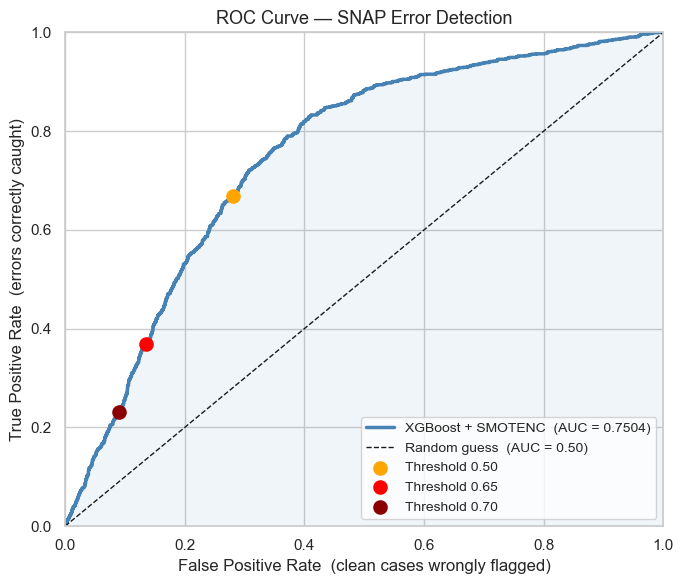

ROC-AUC = 0.7504
Interpretation: the model correctly ranks a random error above a random clean case 75% of the time.


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
fpr, tpr, thr_roc = roc_curve(y, y_prob)
auc_val = roc_auc_score(y, y_prob)

ax.plot(fpr, tpr, lw=2.5, color='steelblue', label=f'XGBoost + SMOTENC  (AUC = {auc_val:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random guess  (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark our operating thresholds
for t, color, name in [(0.50,'orange','0.50'), (0.65,'red','0.65'), (0.70,'darkred','0.70')]:
    idx   = np.argmin(np.abs(thr_roc - t))
    ax.scatter(fpr[idx], tpr[idx], s=90, color=color, zorder=5, label=f'Threshold {name}')

ax.set_xlabel('False Positive Rate  (clean cases wrongly flagged)', fontsize=12)
ax.set_ylabel('True Positive Rate  (errors correctly caught)', fontsize=12)
ax.set_title('ROC Curve — SNAP Error Detection', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout(); plt.show()
print(f"ROC-AUC = {auc_val:.4f}")
print(f"Interpretation: the model correctly ranks a random error above a random clean case {auc_val:.0%} of the time.")


## 9. Precision-Recall curve


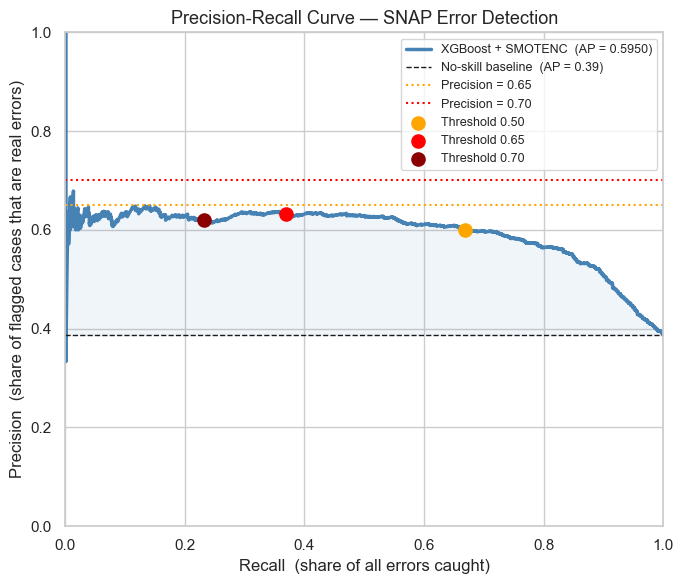

PR-AUC = 0.5950  (baseline = 0.3866)
Lift over baseline: 1.54x


In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
prec_arr, rec_arr, thr_pr = precision_recall_curve(y, y_prob)
ap = average_precision_score(y, y_prob)
base = y.mean()

ax.plot(rec_arr, prec_arr, lw=2.5, color='steelblue', label=f'XGBoost + SMOTENC  (AP = {ap:.4f})')
ax.axhline(base, color='k', ls='--', lw=1, label=f'No-skill baseline  (AP = {base:.2f})')
ax.axhline(0.65, color='orange', ls=':', lw=1.5, label='Precision = 0.65')
ax.axhline(0.70, color='red',    ls=':', lw=1.5, label='Precision = 0.70')

for t, color, name in [(0.50,'orange','0.50'), (0.65,'red','0.65'), (0.70,'darkred','0.70')]:
    idx = np.argmin(np.abs(thr_pr - t))
    ax.scatter(rec_arr[idx], prec_arr[idx], s=90, color=color, zorder=5, label=f'Threshold {name}')

ax.fill_between(rec_arr, prec_arr, base, where=(prec_arr >= base), alpha=0.08, color='steelblue')
ax.set_xlabel('Recall  (share of all errors caught)', fontsize=12)
ax.set_ylabel('Precision  (share of flagged cases that are real errors)', fontsize=12)
ax.set_title('Precision-Recall Curve — SNAP Error Detection', fontsize=13)
ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout(); plt.show()
print(f"PR-AUC = {ap:.4f}  (baseline = {base:.4f})")
print(f"Lift over baseline: {ap/base:.2f}x")


## 10. Threshold sweep — full metric table

This is the most practical output for deciding where to operate.
Pick the row that matches your team's monthly review capacity.


In [11]:
rows = []
for t in np.arange(0.40, 0.85, 0.05):
    preds  = (y_prob >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y, preds).ravel()
    rows.append({
        'Threshold' : round(t, 2),
        'Precision' : round(precision_score(y, preds, zero_division=0), 3),
        'Recall'    : round(recall_score(y, preds, zero_division=0), 3),
        'F1'        : round(f1_score(y, preds, zero_division=0), 3),
        'Specificity': round(tn/(tn+fp) if (tn+fp)>0 else 0, 3),
        'FPR'       : round(fp/(fp+tn) if (fp+tn)>0 else 0, 3),
        'MCC'       : round(matthews_corrcoef(y, preds), 3),
        'Flagged'   : int(preds.sum()),
        '% Load'    : f"{100*preds.mean():.1f}%",
    })

sweep_df = pd.DataFrame(rows)
sweep_df['Primary ★'] = sweep_df['Threshold'].apply(lambda x: '★' if x == PRIMARY_THRESHOLD else '')
sweep_df


,Threshold,Precision,Recall,F1,Specificity,FPR,MCC,Flagged,% Load,Primary ★
0,0.4000,0.5730,0.7800,0.6610,0.6340,0.3660,0.4040,1847,52.6%,
1,0.4500,0.5890,0.7310,0.6530,0.6790,0.3210,0.4000,1683,47.9%,
2,0.5000,0.6000,0.6680,0.6320,0.7190,0.2810,0.3810,1510,43.0%,
3,0.5500,0.6100,0.5870,0.5980,0.7640,0.2360,0.3530,1305,37.2%,
4,0.6000,0.6280,0.4960,0.5540,0.8150,0.1850,0.3290,1071,30.5%,
5,0.6500,0.6320,0.3690,0.4660,0.8640,0.1360,0.2720,793,22.6%,★
6,0.7000,0.6200,0.2320,0.3380,0.9100,0.0900,0.1970,508,14.5%,
7,0.7500,0.6420,0.1300,0.2160,0.9540,0.0460,0.1530,274,7.8%,
8,0.8000,0.6290,0.0490,0.0900,0.9820,0.0180,0.0870,105,3.0%,


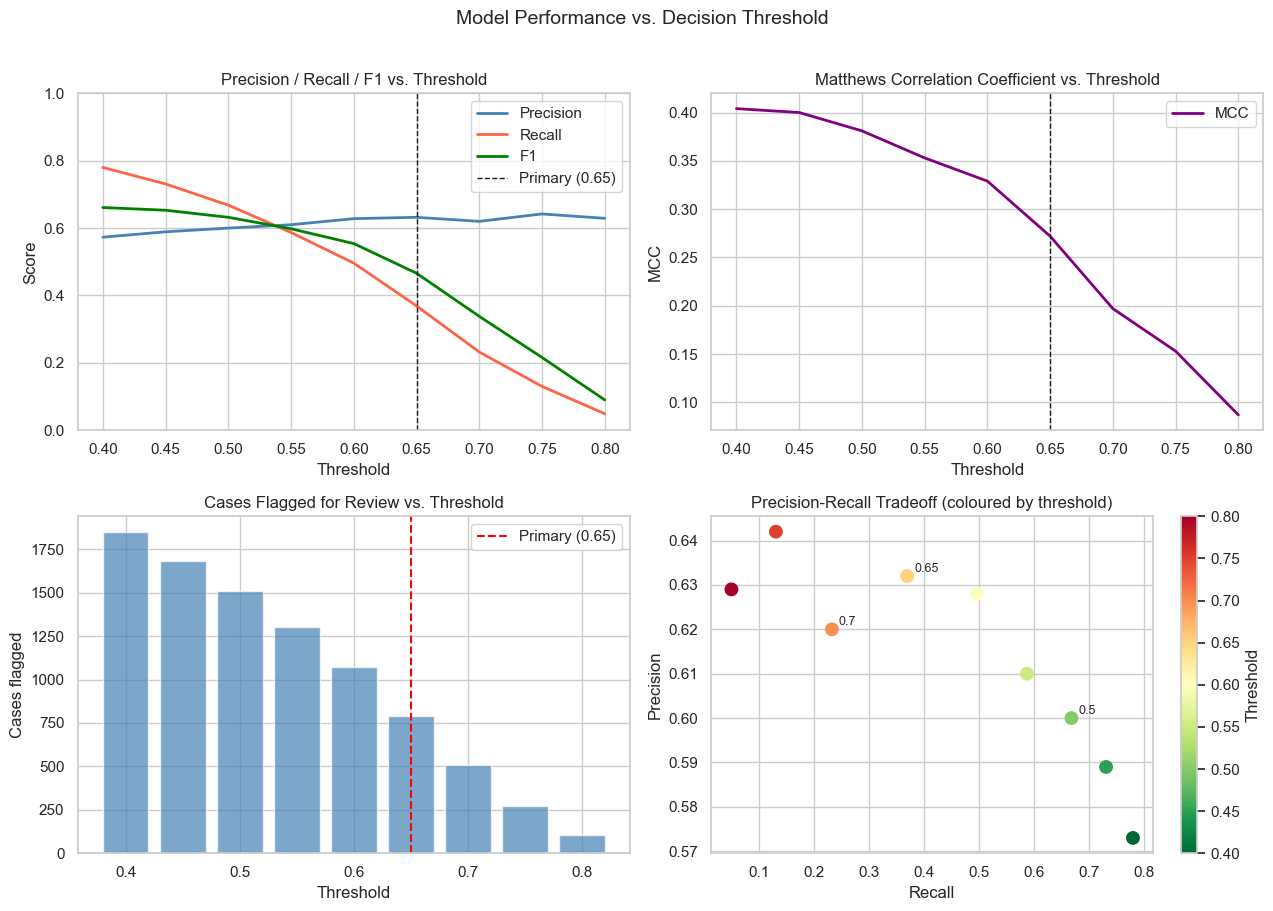

In [12]:
# Visualise the sweep
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

thresholds = [r['Threshold'] for r in rows]
metrics_plot = {
    'Precision':   [r['Precision']    for r in rows],
    'Recall':      [r['Recall']       for r in rows],
    'F1':          [r['F1']           for r in rows],
    'Specificity': [r['Specificity']  for r in rows],
    'MCC':         [r['MCC']          for r in rows],
    '% Flagged':   [float(r['% Load'].strip('%'))/100 for r in rows],
}

# Panel 1: Precision, Recall, F1
ax = axes[0,0]
for m, color in [('Precision','steelblue'),('Recall','tomato'),('F1','green')]:
    ax.plot(thresholds, metrics_plot[m], label=m, lw=2, color=color)
ax.axvline(PRIMARY_THRESHOLD, color='k', ls='--', lw=1, label=f'Primary ({PRIMARY_THRESHOLD})')
ax.set_title('Precision / Recall / F1 vs. Threshold'); ax.legend(); ax.set_ylim([0,1])
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')

# Panel 2: MCC
ax = axes[0,1]
ax.plot(thresholds, metrics_plot['MCC'], lw=2, color='purple', label='MCC')
ax.axvline(PRIMARY_THRESHOLD, color='k', ls='--', lw=1)
ax.set_title("Matthews Correlation Coefficient vs. Threshold")
ax.set_xlabel('Threshold'); ax.set_ylabel('MCC'); ax.legend()

# Panel 3: Cases flagged
ax = axes[1,0]
flagged = [r['Flagged'] for r in rows]
ax.bar(thresholds, flagged, width=0.04, color='steelblue', alpha=0.7)
ax.axvline(PRIMARY_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Primary ({PRIMARY_THRESHOLD})')
ax.set_title('Cases Flagged for Review vs. Threshold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Cases flagged'); ax.legend()

# Panel 4: Precision-Recall tradeoff as scatter
ax = axes[1,1]
sc = ax.scatter(metrics_plot['Recall'], metrics_plot['Precision'],
                c=thresholds, cmap='RdYlGn_r', s=80, zorder=5)
plt.colorbar(sc, ax=ax, label='Threshold')
for t, p, r in zip(thresholds, metrics_plot['Precision'], metrics_plot['Recall']):
    if t in [0.50, 0.65, 0.70]:
        ax.annotate(f'{t}', (r, p), textcoords='offset points', xytext=(5,3), fontsize=9)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Tradeoff (coloured by threshold)')

plt.suptitle('Model Performance vs. Decision Threshold', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 11. Top-N% precision — capacity-based review


In [13]:
order = np.argsort(-y_prob)
rows_lift = []
for pct in [1,2,3,4,5,6,7,8,10,12,15,20,25,30]:
    k      = max(1, int(np.ceil(n * pct / 100)))
    top_k  = order[:k]
    tp_k   = y.iloc[top_k].sum()
    p_k    = tp_k / k
    t_k    = y_prob[top_k[-1]]
    fp_k   = k - tp_k
    rows_lift.append({
        '% Reviewed'    : f'{pct}%',
        'N Cases'       : k,
        'Threshold'     : round(t_k, 3),
        'Precision'     : round(p_k, 3),
        'Errors Found'  : int(tp_k),
        'False Alarms'  : int(fp_k),
        '% of All Errors Caught': f"{100*tp_k/y.sum():.1f}%",
        'Lift vs Random': round(p_k / y.mean(), 2),
    })

lift_df = pd.DataFrame(rows_lift)
lift_df


,% Reviewed,N Cases,Threshold,Precision,Errors Found,False Alarms,% of All Errors Caught,Lift vs Random
0,1%,36,0.8350,0.6110,22,14,1.6%,1.5800
1,2%,71,0.8120,0.6340,45,26,3.3%,1.6400
2,3%,106,0.8000,0.6230,66,40,4.9%,1.6100
3,4%,141,0.7830,0.6310,89,52,6.6%,1.6300
4,5%,176,0.7710,0.6140,108,68,8.0%,1.5900
5,6%,211,0.7640,0.6300,133,78,9.8%,1.6300
6,7%,246,0.7560,0.6460,159,87,11.7%,1.6700
7,8%,281,0.7490,0.6440,181,100,13.3%,1.6700
8,10%,351,0.7330,0.6270,220,131,16.2%,1.6200
9,12%,422,0.7200,0.6280,265,157,19.5%,1.6200


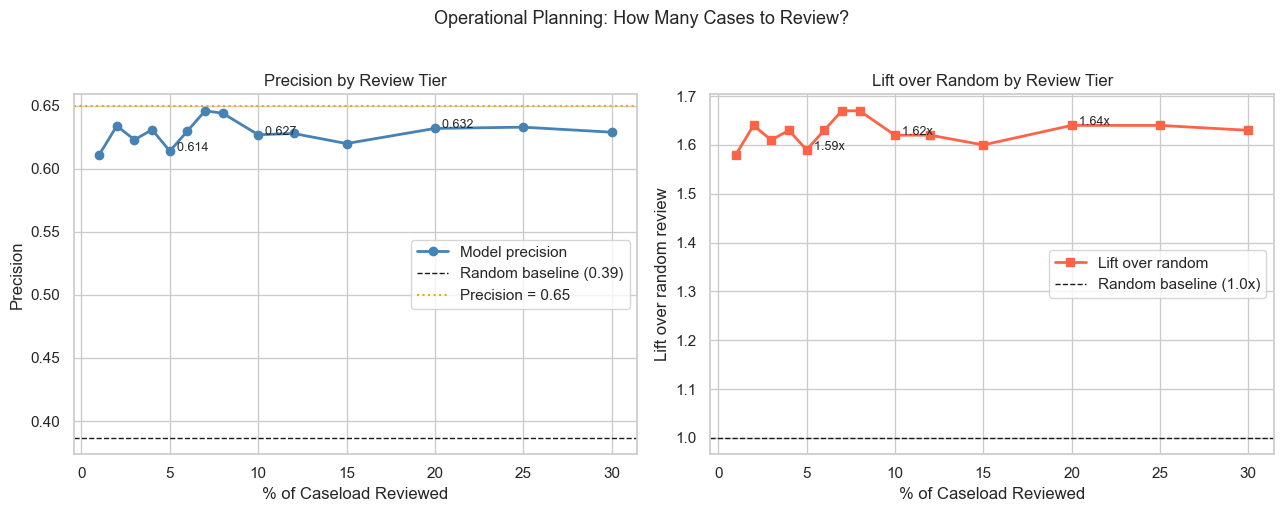

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

pcts  = [int(r['% Reviewed'].strip('%')) for r in rows_lift]
precs = [r['Precision'] for r in rows_lift]
lifts = [r['Lift vs Random'] for r in rows_lift]

ax1.plot(pcts, precs, 'o-', lw=2, color='steelblue', label='Model precision')
ax1.axhline(y.mean(), color='k', ls='--', lw=1, label=f'Random baseline ({y.mean():.2f})')
ax1.axhline(0.65, color='orange', ls=':', lw=1.5, label='Precision = 0.65')
for pct in [5, 10, 20]:
    row = [r for r in rows_lift if r['% Reviewed'] == f'{pct}%'][0]
    ax1.annotate(f"  {row['Precision']:.3f}", (pct, row['Precision']), fontsize=9)
ax1.set_xlabel('% of Caseload Reviewed'); ax1.set_ylabel('Precision')
ax1.set_title('Precision by Review Tier'); ax1.legend()

ax2.plot(pcts, lifts, 's-', lw=2, color='tomato', label='Lift over random')
ax2.axhline(1.0, color='k', ls='--', lw=1, label='Random baseline (1.0x)')
for pct in [5, 10, 20]:
    row = [r for r in rows_lift if r['% Reviewed'] == f'{pct}%'][0]
    ax2.annotate(f"  {row['Lift vs Random']}x", (pct, row['Lift vs Random']), fontsize=9)
ax2.set_xlabel('% of Caseload Reviewed'); ax2.set_ylabel('Lift over random review')
ax2.set_title('Lift over Random by Review Tier'); ax2.legend()

plt.suptitle('Operational Planning: How Many Cases to Review?', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 12. Score distribution by actual outcome

This shows whether the model's scores are well-separated between true errors
and clean cases.

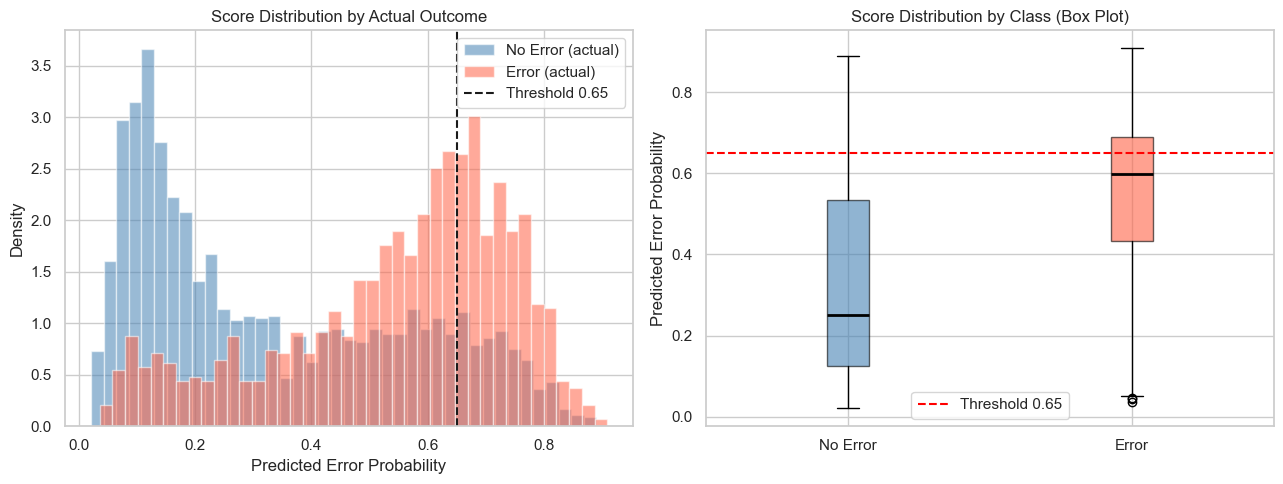

Median score — No Error: 0.251
Median score — Error   : 0.599
Overlap makes the model uncertain for many cases — this is why AUC tops out at 0.75.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE by class
ax = axes[0]
for val, label, color in [(0,'No Error (actual)','steelblue'),(1,'Error (actual)','tomato')]:
    scores = y_prob[y == val]
    ax.hist(scores, bins=40, alpha=0.55, color=color, label=label, density=True)
ax.axvline(PRIMARY_THRESHOLD, color='k', ls='--', lw=1.5, label=f'Threshold {PRIMARY_THRESHOLD}')
ax.set_xlabel('Predicted Error Probability'); ax.set_ylabel('Density')
ax.set_title('Score Distribution by Actual Outcome'); ax.legend()

# Box plot
ax = axes[1]
box_data = [y_prob[y==0], y_prob[y==1]]
bp = ax.boxplot(box_data, labels=['No Error','Error'], patch_artist=True,
                medianprops={'color':'black','lw':2})
for patch, color in zip(bp['boxes'], ['steelblue','tomato']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(PRIMARY_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold {PRIMARY_THRESHOLD}')
ax.set_ylabel('Predicted Error Probability')
ax.set_title('Score Distribution by Class (Box Plot)'); ax.legend()

plt.tight_layout(); plt.show()

print("Median score — No Error:", round(np.median(y_prob[y==0]),3))
print("Median score — Error   :", round(np.median(y_prob[y==1]),3))
print("Overlap makes the model uncertain for many cases — this is why AUC tops out at 0.75.")


## 13. Calibration plot



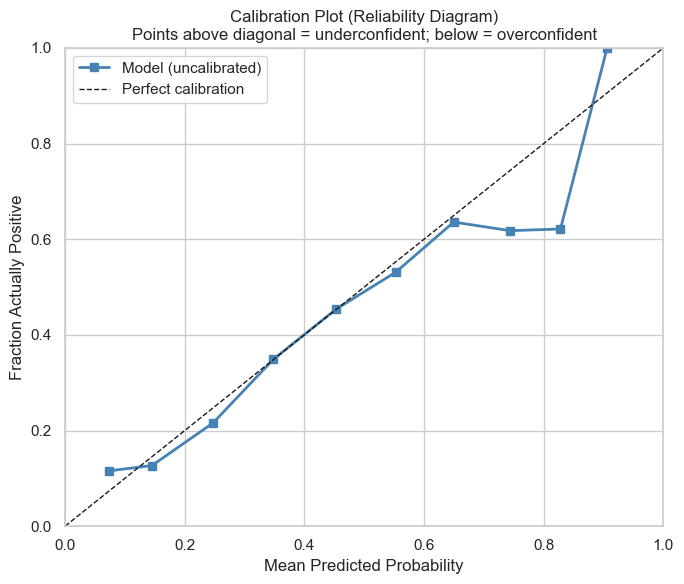

Calibration note:
  Training error rate : 38.7%
  True caseload rate  : ~6-10%
  A score of 0.65 corresponds to true P(error) ≈ 0.17-0.26 in deployment.
  Use scores for ranking only, not as literal probabilities.


In [16]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))
fraction_pos, mean_pred = calibration_curve(y, y_prob, n_bins=10, strategy='uniform')

ax.plot(mean_pred, fraction_pos, 's-', lw=2, color='steelblue', label='Model (uncalibrated)')
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction Actually Positive')
ax.set_title('Calibration Plot (Reliability Diagram)\n'
             'Points above diagonal = underconfident; below = overconfident')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout(); plt.show()

print("Calibration note:")
print(f"  Training error rate : {y.mean():.1%}")
print(f"  True caseload rate  : ~6-10%")
print(f"  A score of 0.65 corresponds to true P(error) ≈ 0.17-0.26 in deployment.")
print(f"  Use scores for ranking only, not as literal probabilities.")


## 14. Feature importance

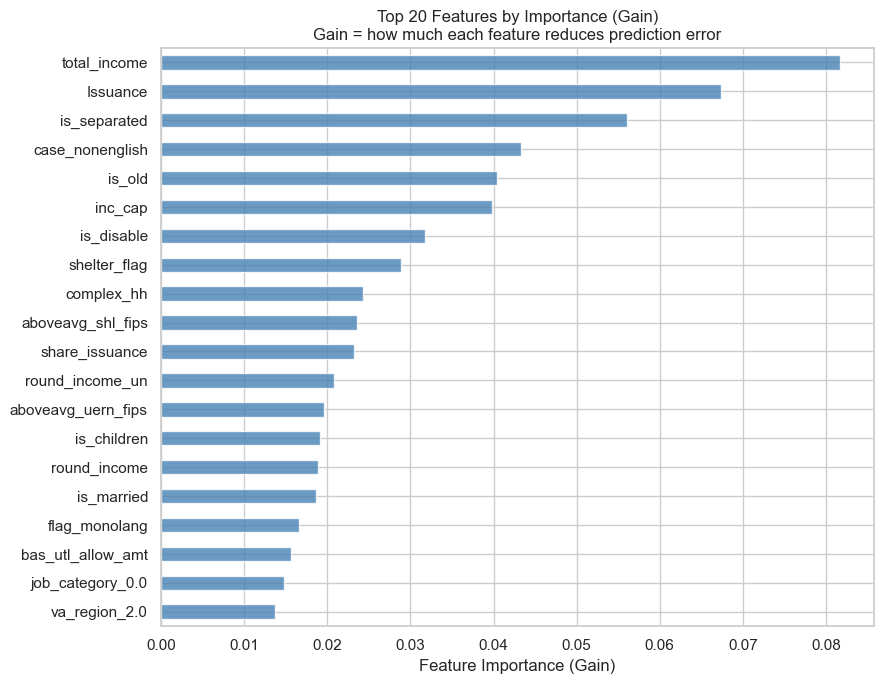


Top 20 features:
total_income         0.0817
Issuance             0.0674
is_separated         0.0561
case_nonenglish      0.0434
is_old               0.0404
inc_cap              0.0398
is_disable           0.0317
shelter_flag         0.0289
complex_hh           0.0242
aboveavg_shl_fips    0.0236
share_issuance       0.0232
round_income_un      0.0208
aboveavg_uern_fips   0.0196
is_children          0.0191
round_income         0.0189
is_married           0.0186
flag_monolang        0.0166
bas_utl_allow_amt    0.0156
job_category_0.0     0.0147
va_region_2.0        0.0137

── Feature interpretation (top 20) ─────────────────────────────────────
Feature                          Importance  Plain-English meaning
------------------------------------------------------------------------------------------
  total_income                       0.0817  Sum of earned + unearned + self-employment income
  Issuance                           0.0674  SNAP benefit dollar amount actually issued
  is_se

In [17]:
# Fit final model on full data with SMOTENC
sm_full          = SMOTENC(categorical_features=cat_indices, random_state=SEED, k_neighbors=5)
X_res_f, y_res_f = sm_full.fit_resample(X_np, y_np)
X_res_f_df       = pd.DataFrame(X_res_f, columns=X_raw.columns)
X_full_ohe       = align_ohe(pd.get_dummies(X_res_f_df, columns=cat_col_names, drop_first=False), all_cols)

final_model = xgb.XGBClassifier(**PARAMS)
final_model.fit(X_full_ohe.values, y_res_f)

imp = (pd.Series(final_model.feature_importances_, index=X_full_ohe.columns)
         .sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(9, 7))
imp[::-1].plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Top 20 Features by Importance (Gain)\n'
             'Gain = how much each feature reduces prediction error', fontsize=12)
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout(); plt.show()

print("\nTop 20 features:")
print(imp.to_string())

# ── Plain-English feature dictionary ─────────────────────────────────────────
FEATURE_LABELS = {
    # Engineered features
    'total_income'      : "Sum of earned + unearned + self-employment income",
    'income_deviation'  : "Gap between benefit issued and expected amount given income",
    'share_issuance'    : "Benefit issued as % of household maximum — high = near-limit case",
    'inc_cap'           : "Income per household member — controls for family size",
    'earned_share'      : "Fraction of income that is earned wages (vs. unearned/transfer)",
    'unearned_share'    : "Fraction of income from unearned sources (SSI, SSDI, etc.)",
    'self_empl_share'   : "Fraction of income from self-employment — harder to verify",
    'share_rent'        : "Shelter cost as fraction of income — large share = deduction risk",
    'caseload_cap'      : "Caseworker caseload per year of DSS tenure — proxy for workload pressure",
    'caseload_sq'       : "Square root of caseload — diminishing sensitivity to very large caseloads",
    'job_tenure_sq'     : "Square root of caseworker job tenure — proxy for experience",
    'complex_hh'        : "Count of complexity flags: elderly + disabled + children (0-3)",
    'round_income'      : "Flag: earned income is a round number (possible estimation, not paystub)",
    'round_income_un'   : "Flag: unearned income is a round number (same concern)",
    'flag_inchh'        : "Flag: household ≥3 people with income ≥$1,500 — complex income cases",
    'med_exp_flag'      : "Flag: household has a medical expense deduction claimed",
    'shelter_flag'      : "Flag: household claims a shelter cost deduction",
    # Raw data features
    'case_ern_incm_amt'  : "Dollar amount of earned income reported on the case",
    'case_uern_incm_amt' : "Dollar amount of unearned income (SSI, unemployment, etc.)",
    'Issuance'           : "SNAP benefit dollar amount actually issued",
    'tot_shl_cost_amt'   : "Total shelter cost (rent/mortgage) used in benefit calculation",
    'family_size'        : "Number of people in the household",
    'dss_tenure'         : "Years caseworker has been at DSS",
    'job_tenure'         : "Years caseworker has been in current position",
    'caseload'           : "Number of cases assigned to this caseworker",
    'med_age'            : "Median age of household members",
    'av_age'             : "Average age of household members",
    # Categoricals (OHE)
    'va_region'          : "Virginia DSS region — Northern / Central / Western / etc.",
    'grouprace'          : "Race/ethnicity category of household head",
    'job_category'       : "Caseworker job classification",
    'max_educ'           : "Maximum education level in household",
    # ── IMPORTANT: Type ──────────────────────────────────────────────────────
    'Type'               : "⚠ QC review completeness: Complete / Incomplete. "
                            "'Not subject to review' cases have been filtered out above. "
                            "If Type is a top feature, the model may be partly learning 'Incomplete "
                            "cases have more errors' — a reviewable rule, not a learned pattern.",
}

print("\n── Feature interpretation (top 20) ─────────────────────────────────────")
print(f"{'Feature':<30} {'Importance':>12}  Plain-English meaning")
print("-" * 90)
for feat, importance in imp.items():
    # Match base feature name (strip OHE suffix like _Northern)
    base = feat
    label = FEATURE_LABELS.get(base)
    if label is None:
        for key in FEATURE_LABELS:
            if feat.startswith(key):
                label = FEATURE_LABELS[key] + f"  [category: {feat[len(key)+1:]}]"
                break
    if label is None:
        label = "(see feature engineering section above)"
    print(f"  {feat:<28} {importance:>12.4f}  {label}")

# Flag if Type is in top 5
top5 = list(imp.index[:5])
type_feats = [f for f in top5 if f.startswith('Type')]
if type_feats:
    print(f"\n⚠  {type_feats} is in the top 5 features.")
    print("   Investigate whether the model is learning a category rule vs. a genuine signal.")
    print("   Consider removing Type from features entirely and checking AUC impact.")
